In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle
from matplotlib.offsetbox import (TextArea, DrawingArea, OffsetImage,
                                  AnnotationBbox)

In [4]:
np.random.seed(42)

In [58]:
def plotDataAndCov(data, title, color=None):
    ACov = np.cov(data, rowvar=False, bias=True)
    cov_rounded = np.round(ACov, 2)
    cov_str = f'Covariance matrix \n{cov_rounded}\n'
    
    cov_str = 'Covariance Matrix\n${},{}$ \n${},{}$'.format(cov_rounded[0,0],
                                                                cov_rounded[0,1],
                                                                cov_rounded[1,0],
                                                                cov_rounded[1,1])
                                                           
                
        
    fig, ax = plt.subplots()
    ax.scatter(data[:,0], data[:,1], s=10, marker='o', c=color)
    
    
    xy = [0.1,0.8]
    plt.xlim([0, 1])
    plt.ylim([0, 1])

    plt.suptitle(title)
    if title != 'Feature Scaled':
        xy = [-4, 2.5]
        plt.xlim([-5, 5])
        plt.ylim([-5, 5])
        
    plt.text(xy[0], xy[1], cov_str)
    

In [54]:
def feature_scaling(X):
    return (X - X.min()) / (X.max() - X.min())

def center(X):
    return X - np.mean(X, axis = 0)

def standardize(X):
    return center(X)/np.std(X, axis = 0)

def decorrelate(X):
    X = center(X)
    cov = np.cov(X, rowvar=False)
    # Calculate the eigenvalues and eigenvectors of the covariance matrix
    eigVals, eigVecs = np.linalg.eig(cov)
    # Apply the eigenvectors to X
    decorrelated = X.dot(eigVecs)
    return decorrelated

def whiten(X):
    X = center(X)
    cov = np.cov(X, rowvar=False)
    # Calculate the eigenvalues and eigenvectors of the covariance matrix
    eigVals, eigVecs = np.linalg.eig(cov)
    # Apply the eigenvectors to X
    decorrelated = X.dot(eigVecs)
    # Rescale the decorrelated data
    whitened = decorrelated / np.sqrt(eigVals + 1e-5)
    return whitened

In [55]:
n_samples = 1000
mu = [1, -1]
sigma = [[1, .8],[.8, 2]]
X =  np.random.multivariate_normal(mu, sigma, n_samples)


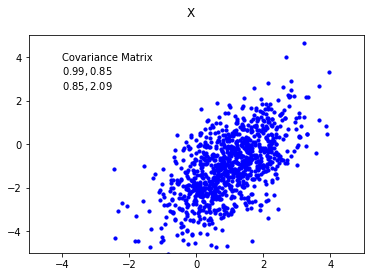

In [56]:
plotDataAndCov(X, 'X', color='b')

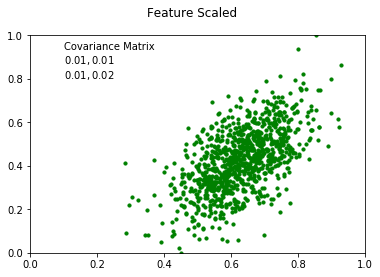

In [59]:
plotDataAndCov(feature_scaling(X), 'Feature Scaled', color='g')

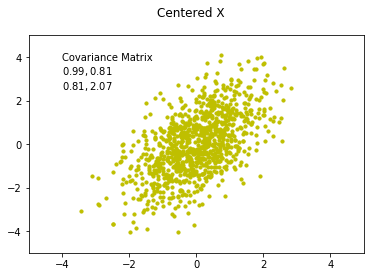

In [334]:
plotDataAndCov(center(X), 'Centered X', color='y')

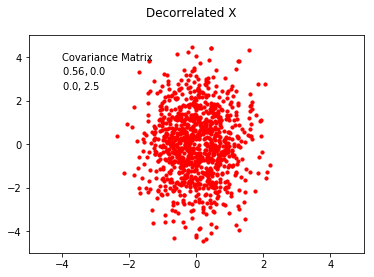

In [335]:
plotDataAndCov(decorrelate(X), 'Decorrelated X', color='r')

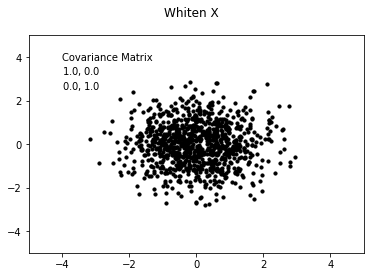

In [336]:
plotDataAndCov(whiten(X), 'Whiten X', color='k')

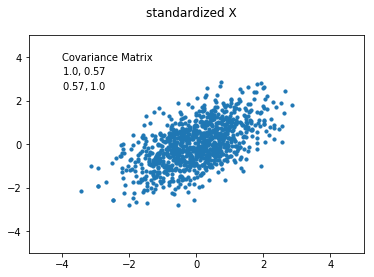

In [337]:
plotDataAndCov(standardize(X), 'standardized X')